# Chi-Quadrat-Tabelle und Verteilung – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/tabelle-chi-quadrat)

Die **Chi-Quadrat-Verteilung** ergibt sich aus der Summe von $n$ quadrierten
standardnormalverteilten Zufallsvariablen, wobei $n$ die **Freiheitsgrade (df)** sind.

$$\chi^2 = \sum_{i=1}^{n} Z_i^2, \quad Z_i \sim N(0,1)$$

**Anwendung beim Chi-Quadrat-Test:**
$$\chi^2_{berechnet} > \chi^2_{krit}(df, \alpha) \Rightarrow H_0 \text{ verwerfen}$$

**Freiheitsgrade beim Chi-Quadrat-Test:**

| Anwendung | df |
|---|---|
| Anpassungstest (k Kategorien) | k − 1 |
| Unabhängigkeitstest (r × c Tabelle) | (r − 1)(c − 1) |

**Tabelle lesen:**
- Zeile = df (Freiheitsgrade)
- Spalte = Signifikanzniveau α (rechtsseitig)
- Zellwert = kritischer χ²-Wert
- **χ²-Verteilung ist immer rechtsseitig!**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Chi-Quadrat-Verteilung für verschiedene df

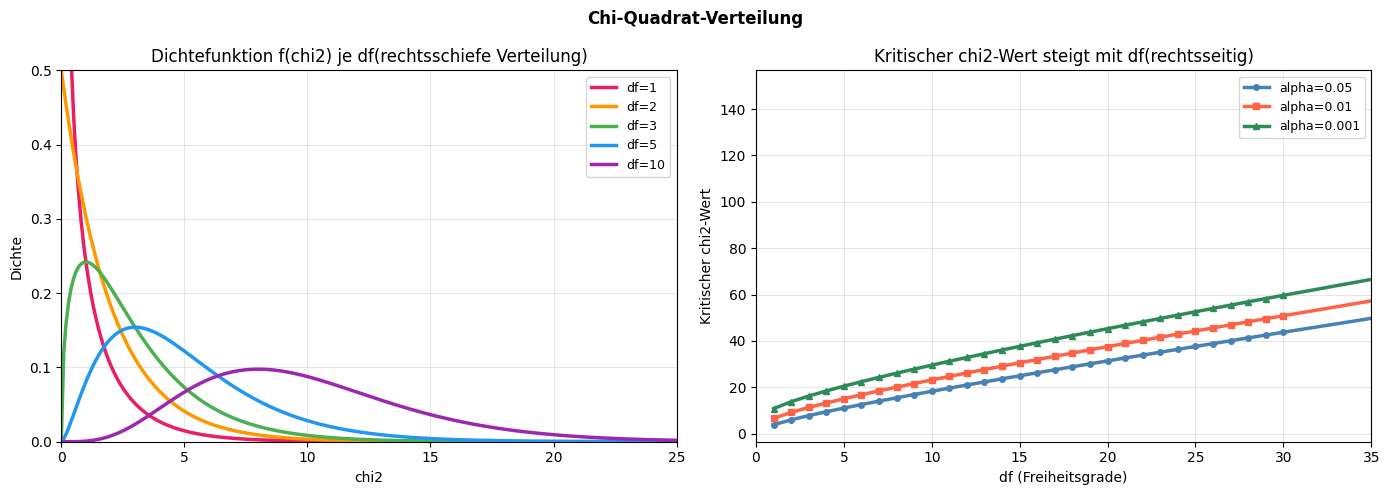

In [2]:
x = np.linspace(0, 40, 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chi-Quadrat-Verteilung", fontsize=12, fontweight="bold")

farben = ["#E91E63", "#FF9800", "#4CAF50", "#2196F3", "#9C27B0"]
df_liste = [1, 2, 3, 5, 10]
for df_v, fc in zip(df_liste, farben):
    pdf_v = chi2.pdf(x, df_v)
    axes[0].plot(x, pdf_v, color=fc, linewidth=2.5, label="df=" + str(df_v))

axes[0].set_title("Dichtefunktion f(chi2) je df(rechtsschiefe Verteilung)")
axes[0].set_xlabel("chi2")
axes[0].set_ylabel("Dichte")
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 25)
axes[0].set_ylim(0, 0.5)
axes[0].grid(alpha=0.3)

# Kritische Werte je df
df_plot = list(range(1, 31)) + [40, 50, 60, 80, 100]
chi2_05  = [round(chi2.ppf(0.95, df_v), 3) for df_v in df_plot]
chi2_01  = [round(chi2.ppf(0.99, df_v), 3) for df_v in df_plot]
chi2_001 = [round(chi2.ppf(0.999, df_v), 3) for df_v in df_plot]

axes[1].plot(df_plot[:35], chi2_05[:35],  "o-", color="steelblue",
             linewidth=2.5, markersize=4, label="alpha=0.05")
axes[1].plot(df_plot[:35], chi2_01[:35],  "s-", color="tomato",
             linewidth=2.5, markersize=4, label="alpha=0.01")
axes[1].plot(df_plot[:35], chi2_001[:35], "^-", color="seagreen",
             linewidth=2.5, markersize=4, label="alpha=0.001")
axes[1].set_title("Kritischer chi2-Wert steigt mit df(rechtsseitig)")
axes[1].set_xlabel("df (Freiheitsgrade)")
axes[1].set_ylabel("Kritischer chi2-Wert")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 35)

plt.tight_layout()
plt.show()

## 2. Chi-Quadrat-Tabelle (numiqo)

**Kritische χ²-Werte** je df und Signifikanzniveau – exakt wie auf numiqo.de.

In [3]:
# Chi-Quadrat-Tabelle exakt wie numiqo
df_zeilen = list(range(1, 31)) + [40, 50, 60, 70, 80, 90, 100]
# Signifikanzniveaus (alpha, rechtsseitig): chi2.ppf(1-alpha, df)
alphas = [0.995, 0.975, 0.2, 0.1, 0.05, 0.025, 0.02, 0.01, 0.005, 0.002, 0.001]
# ppf(1-alpha, df) gibt den kritischen chi2-Wert für rechtsseitigen Test
# Achtung: Spalten 0.995 und 0.975 sind LINKSSEITIGE kritische Werte
# (entsprechen ppf(0.005, df) und ppf(0.025, df))

tabelle = {}
for df_v in df_zeilen:
    row = {}
    for alpha in alphas:
        if alpha in [0.995, 0.975]:
            # Linksseitig: ppf(alpha, df) - kleine Werte
            t_krit_v = round(chi2.ppf(alpha, df_v), 3)
        else:
            # Rechtsseitig: ppf(1-alpha, df)
            t_krit_v = round(chi2.ppf(1 - alpha, df_v), 3)
        row[str(alpha)] = t_krit_v
    tabelle[str(df_v)] = row

df_tab = pd.DataFrame(tabelle).T
df_tab.index.name = "df"
df_tab.columns = [str(a) for a in alphas]

print("Chi-Quadrat-Tabelle (kritische Werte)")
print("Spalte = Signifikanzniveau alpha (rechtsseitig, ausser 0.995/0.975)")
print()
# Kompakte Ausgabe erste 15 df
print(df_tab.head(15).to_string())
print("...")
print(df_tab.tail(7).to_string())
print()
print("Lesebeispiele:")
print("df=1,  alpha=0.05 -> chi2_krit=" + str(round(chi2.ppf(0.95, 1), 3)) +
      "  (numiqo: 3.841)")
print("df=3,  alpha=0.05 -> chi2_krit=" + str(round(chi2.ppf(0.95, 3), 3)) +
      "  (numiqo: 7.815)")
print("df=10, alpha=0.05 -> chi2_krit=" + str(round(chi2.ppf(0.95, 10), 3)) +
      "  (numiqo: 18.307)")

Chi-Quadrat-Tabelle (kritische Werte)
Spalte = Signifikanzniveau alpha (rechtsseitig, ausser 0.995/0.975)

     0.995   0.975     0.2     0.1    0.05   0.025    0.02    0.01   0.005   0.002   0.001
df                                                                                        
1    7.879   5.024   1.642   2.706   3.841   5.024   5.412   6.635   7.879   9.550  10.828
2   10.597   7.378   3.219   4.605   5.991   7.378   7.824   9.210  10.597  12.429  13.816
3   12.838   9.348   4.642   6.251   7.815   9.348   9.837  11.345  12.838  14.796  16.266
4   14.860  11.143   5.989   7.779   9.488  11.143  11.668  13.277  14.860  16.924  18.467
5   16.750  12.833   7.289   9.236  11.070  12.833  13.388  15.086  16.750  18.907  20.515
6   18.548  14.449   8.558  10.645  12.592  14.449  15.033  16.812  18.548  20.791  22.458
7   20.278  16.013   9.803  12.017  14.067  16.013  16.622  18.475  20.278  22.601  24.322
8   21.955  17.535  11.030  13.362  15.507  17.535  18.168  20.090  21.955

In [7]:
# p-Wert aus chi2-Wert
def p_aus_chi2(chi2_val, df_v):
    return 1 - chi2.cdf(chi2_val, df_v)

def chi2_krit(df_v, alpha=0.05):
    return round(chi2.ppf(1 - alpha, df_v), 4)

print("p-Wert aus chi2-Wert")
print()
print("chi2   df    p-Wert    signifikant?")
print()
for chi2_v, df_v in [(3.84,1), (5.99,2), (7.81,3), (9.49,4),
                     (11.07,5), (18.31,10), (15.51,8)]:
    p = round(p_aus_chi2(chi2_v, df_v), 4)
    sig = "JA" if p < 0.05 else "nein"
    print(str(round(chi2_v,2)).rjust(6) + "  " + str(df_v).rjust(4) +
          "   " + str(p).ljust(8) + "  " + sig)

print()
print("Kritische chi2-Werte")
print()
print("df     alpha=0.10   alpha=0.05   alpha=0.01   alpha=0.001")
print()
for df_v in [1, 2, 3, 4, 5, 10, 15, 20, 30]:
    vals = [chi2_krit(df_v, a) for a in [0.10, 0.05, 0.01, 0.001]]
    print(str(df_v).rjust(4) + "   " +
          "  ".join(str(v).rjust(10) for v in vals))

p-Wert aus chi2-Wert

chi2   df    p-Wert    signifikant?

  3.84     1   0.05      nein
  5.99     2   0.05      nein
  7.81     3   0.0501    nein
  9.49     4   0.05      nein
 11.07     5   0.05      nein
 18.31    10   0.05      nein
 15.51     8   0.05      nein

Kritische chi2-Werte

df     alpha=0.10   alpha=0.05   alpha=0.01   alpha=0.001

   1       2.7055      3.8415      6.6349     10.8276
   2       4.6052      5.9915      9.2103     13.8155
   3       6.2514      7.8147     11.3449     16.2662
   4       7.7794      9.4877     13.2767     18.4668
   5       9.2364     11.0705     15.0863      20.515
  10      15.9872      18.307     23.2093     29.5883
  15      22.3071     24.9958     30.5779     37.6973
  20       28.412     31.4104     37.5662     45.3147
  30       40.256      43.773     50.8922     59.7031


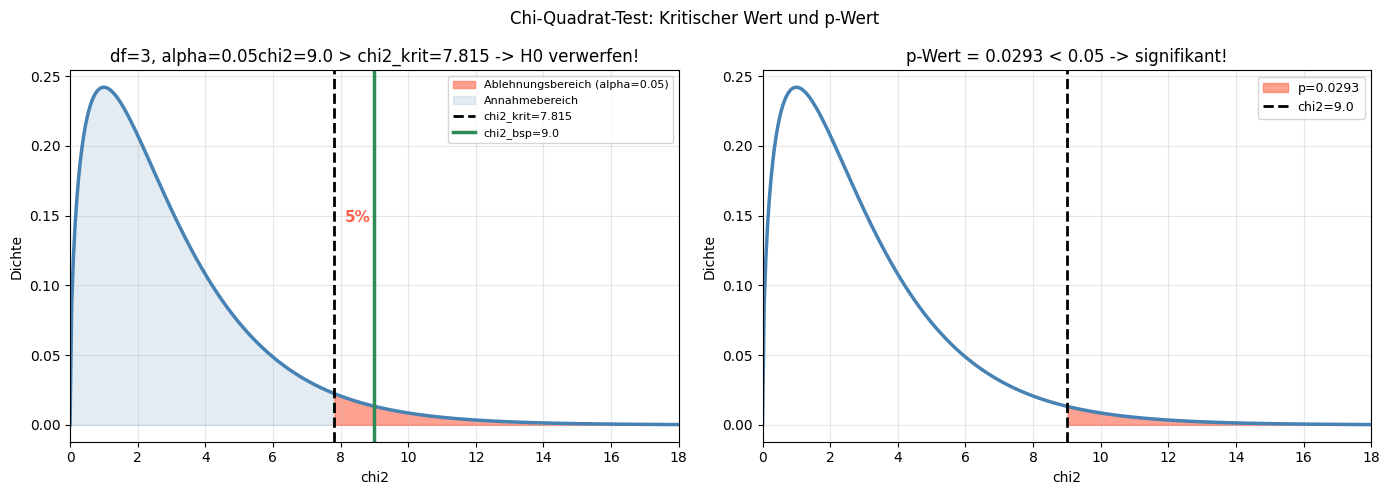

In [5]:
# Visualisierung: Ablehnungsbereich + p-Wert
df_bsp = 3
chi2_bsp = 9.0
chi2_krit_bsp = chi2.ppf(0.95, df_bsp)
p_bsp = 1 - chi2.cdf(chi2_bsp, df_bsp)

x_c = np.linspace(0, 20, 400)
pdf_c = chi2.pdf(x_c, df_bsp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chi-Quadrat-Test: Kritischer Wert und p-Wert", fontsize=12)

# 1. Kritischer Bereich
axes[0].plot(x_c, pdf_c, color="steelblue", linewidth=2.5)
axes[0].fill_between(x_c, pdf_c, where=(x_c >= chi2_krit_bsp),
                     color="tomato", alpha=0.6,
                     label="Ablehnungsbereich (alpha=0.05)")
axes[0].fill_between(x_c, pdf_c, where=(x_c < chi2_krit_bsp),
                     color="steelblue", alpha=0.15, label="Annahmebereich")
axes[0].axvline(chi2_krit_bsp, color="black", linestyle="--", linewidth=2,
                label="chi2_krit=" + str(round(chi2_krit_bsp,3)))
axes[0].axvline(chi2_bsp, color="seagreen", linewidth=2.5,
                label="chi2_bsp=" + str(chi2_bsp))
axes[0].text(chi2_krit_bsp + 0.3, pdf_c.max()*0.6, "5%",
             color="tomato", fontsize=11, fontweight="bold")
axes[0].set_title("df=" + str(df_bsp) + ", alpha=0.05chi2=" + str(chi2_bsp) +
                  " > chi2_krit=" + str(round(chi2_krit_bsp,3)) +
                  " -> H0 verwerfen!")
axes[0].set_xlabel("chi2")
axes[0].set_ylabel("Dichte")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 18)

# 2. p-Wert Fläche
axes[1].plot(x_c, pdf_c, color="steelblue", linewidth=2.5)
axes[1].fill_between(x_c, pdf_c, where=(x_c >= chi2_bsp),
                     color="tomato", alpha=0.6,
                     label="p=" + str(round(p_bsp,4)))
axes[1].axvline(chi2_bsp, color="black", linestyle="--", linewidth=2,
                label="chi2=" + str(chi2_bsp))
axes[1].set_title("p-Wert = " + str(round(p_bsp,4)) +
                  " < 0.05 -> signifikant!" if p_bsp < 0.05
                  else "p-Wert = " + str(round(p_bsp,4)))
axes[1].set_xlabel("chi2")
axes[1].set_ylabel("Dichte")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 18)

plt.tight_layout()
plt.show()

## 3. Zusammenfassung

```
Chi-Quadrat-Tabelle und Verteilung – Übersicht
│
├── DEFINITION
│   chi2 = Summe von n quadrierten N(0,1)-Variablen
│   Nur positive Werte, rechtsschiefe Verteilung
│   Mit groesserem df -> symmetrischer
│
├── FREIHEITSGRADE
│   Anpassungstest:       df = k - 1
│   Unabhaengigkeitstest: df = (r-1)*(c-1)
│
├── TABELLE LESEN
│   Zeile = df
│   Spalte = alpha (Signifikanzniveau, rechtsseitig)
│   Zellwert = kritischer chi2-Wert
│   IMMER rechtsseitig! (chi2 > 0, grosser Wert = selten)
│
├── ENTSCHEIDUNGSREGEL
│   chi2_berechnet > chi2_krit -> H0 verwerfen
│   chi2_berechnet <= chi2_krit -> H0 beibehalten
│
├── WICHTIGE WERTE (alpha=0.05)
│   df=1:  chi2_krit = 3.841
│   df=2:  chi2_krit = 5.991
│   df=3:  chi2_krit = 7.815
│   df=4:  chi2_krit = 9.488
│   df=5:  chi2_krit = 11.07
│
└── PYTHON
    from scipy.stats import chi2
    p_wert   = 1 - chi2.cdf(chi2_wert, df)
    chi2_krit = chi2.ppf(1 - alpha, df)
```

---
Quelle: [numiqo.de/tutorial/tabelle-chi-quadrat](https://numiqo.de/tutorial/tabelle-chi-quadrat)